# Interpretability Notebook


This notebook provides a basic interpretability audit for the final tuned Random Forest model.

The goal is not to re-select or re-tune the model. Instead, this notebook explains the final model from two practical angles:

1. **Global feature importance:** identify which variables the Random Forest uses most for salary prediction, if feature names are available.
2. **Player-level residual analysis:** identify players whose observed 2025 salary differs most from the model-predicted salary.

All overpaid or underpaid labels in this notebook are **relative to the model-predicted salary**, not definitive claims about whether a player is truly underpaid or overpaid.


In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

# Check whether the notebook is being run from the project root or from notebooks/.
ROOT = Path.cwd()

if not (ROOT / "results").exists():
    ROOT = ROOT.parent

result_dir = ROOT / "results"
artifact_dir = ROOT / "artifacts"
audit_dir = result_dir / "audit"
audit_dir.mkdir(parents=True, exist_ok=True)

print("Project root:", ROOT)
print("Results directory:", result_dir)
print("Artifacts directory:", artifact_dir)
print("Audit output directory:", audit_dir)


Project root: /Users/elenaaxinn/Desktop/project
Results directory: /Users/elenaaxinn/Desktop/project/results
Artifacts directory: /Users/elenaaxinn/Desktop/project/artifacts
Audit output directory: /Users/elenaaxinn/Desktop/project/results/audit


## 1. Load final model and prediction output

The final tuned model is loaded from `artifacts/best_model.joblib`.

The player-level 2025 prediction output is loaded from `results/tuned_predictions.csv`.


In [3]:
model_path = artifact_dir / "best_model.joblib"
model = joblib.load(model_path)

print("Loaded model type:", type(model))
model


Loaded model type: <class 'sklearn.ensemble._forest.RandomForestRegressor'>


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",400
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

 The cell below loads the saved 2025 prediction output and recomputes residuals using the same definition as `model_testing.ipynb`. This makes the interpretability notebook self-contained and ensures that the later residual analysis uses a consistent direction.

In [4]:
pred_path = result_dir / "tuned_predictions.csv"
pred_df = pd.read_csv(pred_path).copy()

required_cols = {"player", "team", "group", "actual", "predicted"}
missing_cols = required_cols - set(pred_df.columns)

if missing_cols:
    raise ValueError(f"Missing required columns in tuned_predictions.csv: {missing_cols}")

# Match the residual definition used in model_testing.ipynb:
# residual = predicted - actual
pred_df["residual"] = pred_df["predicted"] - pred_df["actual"]
pred_df["abs_error"] = pred_df["residual"].abs()

pred_df[[
    "player",
    "team",
    "group",
    "actual",
    "predicted",
    "residual",
    "abs_error"
]].head()


,player,team,group,actual,predicted,residual,abs_error
0,A'ja Wilson,LVA,veteran,200000,214155.701628,14155.701628,14155.701628
1,Napheesa Collier,MIN,unknown,214284,200972.099195,-13311.900805,13311.900805
2,Kelsey Mitchell,IND,veteran,269244,213155.488619,-56088.511381,56088.511381
3,Kelsey Plum,LAS,veteran,202000,214220.125809,12220.125809,12220.125809
4,Paige Bueckers,DAL,rookie,78831,121931.589132,43100.589132,43100.589132


## 2. Global feature importance

For a Random Forest model, built-in feature importance is a simple global interpretability diagnostic. It shows which features the model used most when making predictions.

This is a model diagnostic, not a causal interpretation. A high feature-importance score does not mean that the feature causes salary to increase or decrease. It only means that the feature was useful to the model's prediction process.


In [5]:
# Try to recover feature names from the fitted model.
# If feature names were not saved in the model object, this section reports that limitation instead of failing.

feature_names = None

if hasattr(model, "feature_names_in_"):
    feature_names = list(model.feature_names_in_)
    print(f"Recovered {len(feature_names)} feature names from model.feature_names_in_.")
else:
    print("The model does not store feature_names_in_. Feature names may need to be recovered from the training notebook.")

if feature_names is not None:
    feature_names[:10]


Recovered 25 feature names from model.feature_names_in_.


In [6]:
# Create feature-importance table if possible.

importance_df = None

if hasattr(model, "feature_importances_") and feature_names is not None:
    if len(feature_names) != len(model.feature_importances_):
        print("Feature name count does not match feature_importances_ length.")
        print("Feature importance table will not be created automatically.")
    else:
        importance_df = (
            pd.DataFrame({
                "feature": feature_names,
                "importance": model.feature_importances_
            })
            .sort_values("importance", ascending=False)
            .reset_index(drop=True)
        )
        display(importance_df.head(20))
else:
    print("Feature importance table cannot be created automatically.")
    print("Reason: either the model does not expose feature_importances_, or feature names are unavailable.")


,feature,importance
0,start_rate,0.498838
1,pts_vet,0.091752
2,fga,0.052493
3,pca1,0.048974
4,group_hardship,0.033800
5,g,0.031985
6,fg_per_g,0.028566
7,pts,0.024006
8,mp,0.023794
9,tov,0.020338


### Feature-importance interpretation

The feature-importance table shows that `start_rate` is the most important feature in the Random Forest model. Its importance score is much larger than the other features, which means the model uses starting-role information heavily when predicting salary.

Other important features include `pts_vet`, `fga`, `pca1`, `group_hardship`, `g`, `fg_per_g`, `pts`, `mp`, and `tov`. These features are mostly related to scoring, playing time, availability, and player group status.

## 3. Player-level prediction error interpretation

Player-level prediction error analysis was already performed in the section 5 of `model_comparison.ipynb`, where the notebook inspected:

1. **largest absolute errors** show the largest prediction mistakes;
2. **largest positive residuals** show players whose predicted salary is much higher than their actual salary, so they appear underpaid relative to the model predicted salary;
3. **smallest residuals** show players whose predicted salary is much lower than their actual salary, so they appear overpaid relative to the model predicted salary.


## 4. Feature-importance plot

This plot visualizes the top 15 feature importances from the final Random Forest model.


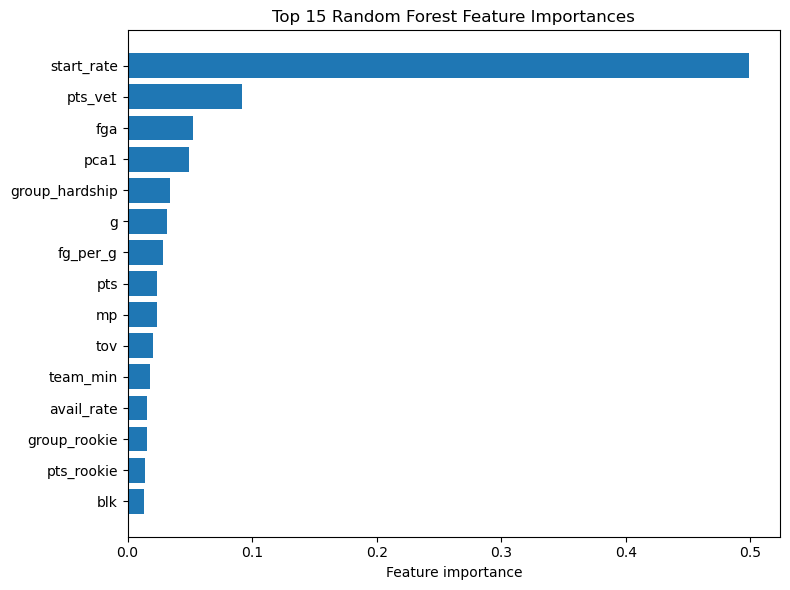

In [7]:
import matplotlib.pyplot as plt

if importance_df is not None:
    top_features = importance_df.head(15).sort_values("importance")

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.barh(top_features["feature"], top_features["importance"])
    ax.set_xlabel("Feature importance")
    ax.set_title("Top 15 Random Forest Feature Importances")
    fig.tight_layout()

    plt.show()
else:
    print("Feature-importance plot skipped because importance_df was not created.")


## 5. Save interpretability audit outputs

This section saves the main interpretability tables to `results/audit/`.


In [8]:
# Save interpretability audit outputs to results/audit/.

audit_dir.mkdir(parents=True, exist_ok=True)

if importance_df is not None:
    importance_path = audit_dir / "feature_importance_audit.csv"
    importance_df.to_csv(importance_path, index=False)
    print(f"Saved feature importance table to: {importance_path}")

if "fig" in globals():
    plot_path = audit_dir / "feature_importance_plot.png"
    fig.savefig(plot_path, dpi=300, bbox_inches="tight")
    print(f"Saved feature importance plot to: {plot_path}")
else:
    print("Feature importance plot was not saved because no figure object was found.")

Saved feature importance table to: /Users/elenaaxinn/Desktop/project/results/audit/feature_importance_audit.csv
Saved feature importance plot to: /Users/elenaaxinn/Desktop/project/results/audit/feature_importance_plot.png


## 6. Interpretability conclusion

Key conclusions:

* This notebook focuses on the final tuned Random Forest model.
* The main interpretability output is the feature-importance analysis.
* `start_rate` is the dominant feature used by the model for salary prediction.
* Other important features are mostly related to scoring, playing time, availability, and player group status.
* Feature importance should be interpreted as a model diagnostic, not as a causal explanation.
* Player-level prediction error interpretation is handled separately in the section 5 of `model_comparison.ipynb`.
* The feature-importance table and plot are saved in `results/audit/` for reporting and review.

